In [5]:
# ============================================================
# ANÁLISE DE QUALIDADE DE METADADOS – SWIFTBANK
# Google Colab – Nível 1 de Governança de Dados
# ============================================================

# Instalar dependências (openpyxl para ler Excel, matplotlib para gráficos)
!pip install openpyxl matplotlib pandas --quiet

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from google.colab import files
import io

print("✅ Bibliotecas instaladas e importadas com sucesso.")

✅ Bibliotecas instaladas e importadas com sucesso.


In [6]:
# ============================================================
# UPLOAD DA PLANILHA
# ============================================================
print("📂 Faça o upload do arquivo 'Exercicio_Excel.xlsx':")
uploaded = files.upload()

# Ler o arquivo enviado
nome_arquivo = list(uploaded.keys())[0]
df = pd.read_excel(io.BytesIO(uploaded[nome_arquivo]), sheet_name="exercicio")

print(f"\n✅ Arquivo '{nome_arquivo}' carregado com sucesso.")
print(f"📊 Total de registros: {len(df)}")
print(f"📋 Total de colunas: {len(df.columns)}")
print(f"\nColunas: {list(df.columns)}")

📂 Faça o upload do arquivo 'Exercicio_Excel.xlsx':


Saving Exercicio_Excel.xlsx to Exercicio_Excel.xlsx

✅ Arquivo 'Exercicio_Excel.xlsx' carregado com sucesso.
📊 Total de registros: 45
📋 Total de colunas: 10

Colunas: ['id_cliente', 'nome_completo', 'data_nascimento', 'tipo_pessoa', 'segmento', 'data_abertura_conta', 'status_conta', 'produto_principal', 'cidade', 'consentimento_marketing']


In [7]:
# ============================================================
# VISÃO GERAL DOS DADOS
# ============================================================
print("=" * 60)
print("VISÃO GERAL DOS DADOS")
print("=" * 60)

print("\n📌 Primeiras 5 linhas:")
display(df.head())

print("\n📌 Tipos de dados:")
print(df.dtypes)

print("\n📌 Valores nulos por coluna:")
print(df.isnull().sum())

print("\n📌 Estatísticas descritivas:")
display(df.describe(include="all"))

VISÃO GERAL DOS DADOS

📌 Primeiras 5 linhas:


,id_cliente,nome_completo,data_nascimento,tipo_pessoa,segmento,data_abertura_conta,status_conta,produto_principal,cidade,consentimento_marketing
0,CLI001,Ana Ribeiro,1990-04-12,PF,Varejo,2021-03-15,Ativa,Conta Corrente,Recife,Sim
1,CLI002,Bruno Salles,1985-11-02,PF,Premium,2019-06-20,Ativa,Investimento,São Paulo,Sim
2,CLI003,Carla Tavares,1978-02-25,PF,Varejo,2020-01-10,Inativa,Cartão,Curitiba,Não
3,CLI004,Diego Monteiro,1995-09-30,PF,Varejo,2022-07-05,Ativa,Empréstimo,Belo Horizonte,Sim
4,CLI005,Elis Prado,1988-12-19,PF,Premium,2018-04-22,Ativa,Conta Corrente,Porto Alegre,Sim



📌 Tipos de dados:
id_cliente                         object
nome_completo                      object
data_nascimento            datetime64[ns]
tipo_pessoa                        object
segmento                           object
data_abertura_conta        datetime64[ns]
status_conta                       object
produto_principal                  object
cidade                             object
consentimento_marketing            object
dtype: object

📌 Valores nulos por coluna:
id_cliente                 0
nome_completo              0
data_nascimento            0
tipo_pessoa                0
segmento                   0
data_abertura_conta        0
status_conta               0
produto_principal          0
cidade                     0
consentimento_marketing    0
dtype: int64

📌 Estatísticas descritivas:


,id_cliente,nome_completo,data_nascimento,tipo_pessoa,segmento,data_abertura_conta,status_conta,produto_principal,cidade,consentimento_marketing
count,45,45,45,45,45,45,45,45,45,45
unique,45,45,NaN,2,3,NaN,3,4,27,2
top,CLI001,Ana Ribeiro,NaN,PF,Varejo,NaN,Ativa,Cartão,São Paulo,Sim
freq,1,1,NaN,39,29,NaN,36,14,4,29
mean,NaN,NaN,1992-11-23 03:12:00,NaN,NaN,2019-12-24 12:48:00,NaN,NaN,NaN,NaN
min,NaN,NaN,1972-02-14 00:00:00,NaN,NaN,2014-10-02 00:00:00,NaN,NaN,NaN,NaN
25%,NaN,NaN,1985-11-02 00:00:00,NaN,NaN,2017-12-15 00:00:00,NaN,NaN,NaN,NaN
50%,NaN,NaN,1992-02-18 00:00:00,NaN,NaN,2020-04-13 00:00:00,NaN,NaN,NaN,NaN
75%,NaN,NaN,1998-08-08 00:00:00,NaN,NaN,2022-05-25 00:00:00,NaN,NaN,NaN,NaN
max,NaN,NaN,2018-09-12 00:00:00,NaN,NaN,2023-11-15 00:00:00,NaN,NaN,NaN,NaN


In [8]:
# ============================================================
# ANÁLISE DE QUALIDADE DOS METADADOS
# ============================================================
print("=" * 60)
print("ANÁLISE DE QUALIDADE DE METADADOS – SWIFTBANK")
print("=" * 60)

total = len(df)

# 1. Duplicidade na chave primária
duplicados = df["id_cliente"].duplicated().sum()
print(f"\n1️⃣ Registros duplicados em 'id_cliente': {duplicados}")

# 2. Valores nulos
nulos = df.isnull().sum()
colunas_com_nulos = nulos[nulos > 0]
if len(colunas_com_nulos) > 0:
    print(f"\n2️⃣ Colunas com valores nulos:")
    print(colunas_com_nulos)
else:
    print(f"\n2️⃣ Nenhuma coluna com valores nulos. ✅")

# 3. Consistência de tipo_pessoa
tipos_validos = {"PF", "PJ"}
tipos_invalidos = df[~df["tipo_pessoa"].isin(tipos_validos)]
print(f"\n3️⃣ Registros com 'tipo_pessoa' inválido: {len(tipos_invalidos)}")
if len(tipos_invalidos) > 0:
    display(tipos_invalidos[["id_cliente", "nome_completo", "tipo_pessoa"]])

# 4. Consistência de status_conta
status_validos = {"Ativa", "Inativa", "Encerrada"}
status_invalidos = df[~df["status_conta"].isin(status_validos)]
print(f"\n4️⃣ Registros com 'status_conta' inválido: {len(status_invalidos)}")
if len(status_invalidos) > 0:
    display(status_invalidos[["id_cliente", "nome_completo", "status_conta"]])

# 5. Consistência de segmento
segmentos_validos = {"Varejo", "Premium", "Empresarial"}
segmentos_invalidos = df[~df["segmento"].isin(segmentos_validos)]
print(f"\n5️⃣ Registros com 'segmento' inválido: {len(segmentos_invalidos)}")

# 6. Consistência de consentimento_marketing
consent_validos = {"Sim", "Não"}
consent_invalidos = df[~df["consentimento_marketing"].isin(consent_validos)]
print(f"\n6️⃣ Registros com 'consentimento_marketing' inválido: {len(consent_invalidos)}")

# 7. Datas inconsistentes
df["data_nascimento"] = pd.to_datetime(df["data_nascimento"], errors="coerce")
df["data_abertura_conta"] = pd.to_datetime(df["data_abertura_conta"], errors="coerce")

datas_nasc_invalidas = df["data_nascimento"].isnull().sum()
datas_abertura_invalidas = df["data_abertura_conta"].isnull().sum()
print(f"\n7️⃣ Datas de nascimento inválidas: {datas_nasc_invalidas}")
print(f"8️⃣ Datas de abertura inválidas: {datas_abertura_invalidas}")

# 9. Data de nascimento posterior à abertura da conta (erro lógico)
df_valido = df.dropna(subset=["data_nascimento", "data_abertura_conta"])
erro_logico = df_valido[df_valido["data_nascimento"] > df_valido["data_abertura_conta"]]
print(f"\n9️⃣ Registros com nascimento posterior à abertura da conta: {len(erro_logico)}")
if len(erro_logico) > 0:
    display(erro_logico[["id_cliente", "nome_completo", "data_nascimento", "data_abertura_conta"]])

ANÁLISE DE QUALIDADE DE METADADOS – SWIFTBANK

1️⃣ Registros duplicados em 'id_cliente': 0

2️⃣ Nenhuma coluna com valores nulos. ✅

3️⃣ Registros com 'tipo_pessoa' inválido: 0

4️⃣ Registros com 'status_conta' inválido: 0

5️⃣ Registros com 'segmento' inválido: 0

6️⃣ Registros com 'consentimento_marketing' inválido: 0

7️⃣ Datas de nascimento inválidas: 0
8️⃣ Datas de abertura inválidas: 0

9️⃣ Registros com nascimento posterior à abertura da conta: 0


In [9]:
# ============================================================
# INDICADORES DE QUALIDADE (KPIs)
# ============================================================
print("=" * 60)
print("INDICADORES DE QUALIDADE – KPIs")
print("=" * 60)

kpis = {
    "Total de registros": total,
    "Registros duplicados": duplicados,
    "Colunas com nulos": len(colunas_com_nulos),
    "Tipos de pessoa inválidos": len(tipos_invalidos),
    "Status de conta inválidos": len(status_invalidos),
    "Segmentos inválidos": len(segmentos_invalidos),
    "Consentimentos inválidos": len(consent_invalidos),
    "Datas de nascimento inválidas": datas_nasc_invalidas,
    "Datas de abertura inválidas": datas_abertura_invalidas,
    "Erros lógicos (nascimento > abertura)": len(erro_logico),
}

# Percentual de qualidade
total_problemas = (
    duplicados + len(tipos_invalidos) + len(status_invalidos) +
    len(segmentos_invalidos) + len(consent_invalidos) +
    datas_nasc_invalidas + datas_abertura_invalidas + len(erro_logico)
)
percentual_qualidade = ((total * 10 - total_problemas) / (total * 10)) * 100

print(f"\n📊 Total de problemas encontrados: {total_problemas}")
print(f"✅ Percentual estimado de qualidade: {percentual_qualidade:.2f}%")

print("\n📋 Resumo dos KPIs:")
for k, v in kpis.items():
    print(f"   • {k}: {v}")

INDICADORES DE QUALIDADE – KPIs

📊 Total de problemas encontrados: 0
✅ Percentual estimado de qualidade: 100.00%

📋 Resumo dos KPIs:
   • Total de registros: 45
   • Registros duplicados: 0
   • Colunas com nulos: 0
   • Tipos de pessoa inválidos: 0
   • Status de conta inválidos: 0
   • Segmentos inválidos: 0
   • Consentimentos inválidos: 0
   • Datas de nascimento inválidas: 0
   • Datas de abertura inválidas: 0
   • Erros lógicos (nascimento > abertura): 0


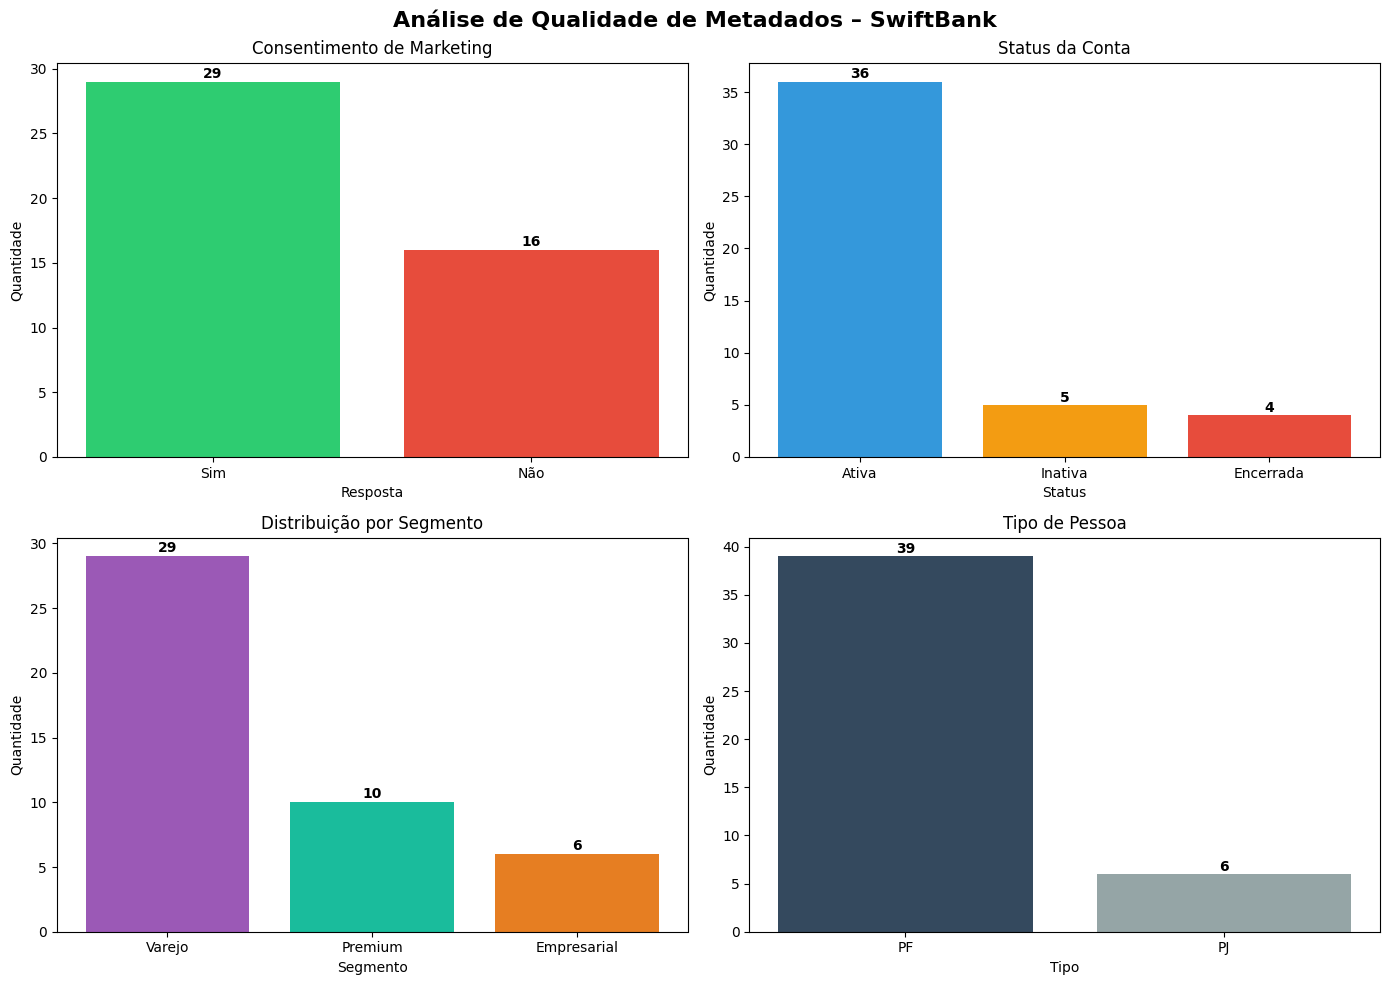


✅ Gráfico salvo como 'grafico_qualidade_swiftbank.png'


In [10]:
# ============================================================
# GRÁFICOS DE QUALIDADE
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Análise de Qualidade de Metadados – SwiftBank", fontsize=16, fontweight="bold")

# Gráfico 1: Consentimento de Marketing
consentimento = df["consentimento_marketing"].value_counts()
axes[0, 0].bar(consentimento.index, consentimento.values, color=["#2ecc71", "#e74c3c"])
axes[0, 0].set_title("Consentimento de Marketing")
axes[0, 0].set_xlabel("Resposta")
axes[0, 0].set_ylabel("Quantidade")
for i, v in enumerate(consentimento.values):
    axes[0, 0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Gráfico 2: Status da Conta
status = df["status_conta"].value_counts()
axes[0, 1].bar(status.index, status.values, color=["#3498db", "#f39c12", "#e74c3c"])
axes[0, 1].set_title("Status da Conta")
axes[0, 1].set_xlabel("Status")
axes[0, 1].set_ylabel("Quantidade")
for i, v in enumerate(status.values):
    axes[0, 1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Gráfico 3: Segmento
segmento = df["segmento"].value_counts()
axes[1, 0].bar(segmento.index, segmento.values, color=["#9b59b6", "#1abc9c", "#e67e22"])
axes[1, 0].set_title("Distribuição por Segmento")
axes[1, 0].set_xlabel("Segmento")
axes[1, 0].set_ylabel("Quantidade")
for i, v in enumerate(segmento.values):
    axes[1, 0].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

# Gráfico 4: Tipo de Pessoa
tipo = df["tipo_pessoa"].value_counts()
axes[1, 1].bar(tipo.index, tipo.values, color=["#34495e", "#95a5a6"])
axes[1, 1].set_title("Tipo de Pessoa")
axes[1, 1].set_xlabel("Tipo")
axes[1, 1].set_ylabel("Quantidade")
for i, v in enumerate(tipo.values):
    axes[1, 1].text(i, v + 0.3, str(v), ha="center", fontweight="bold")

plt.tight_layout()
plt.savefig("grafico_qualidade_swiftbank.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Gráfico salvo como 'grafico_qualidade_swiftbank.png'")

In [11]:
# ============================================================
# EXPORTAR RELATÓRIO
# ============================================================
from datetime import datetime

relatorio = f"""
============================================================
RELATÓRIO DE QUALIDADE DE METADADOS – SWIFTBANK
Gerado em: {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}
============================================================

1. VISÃO GERAL
   Total de registros: {total}
   Total de colunas: {len(df.columns)}

2. INDICADORES DE QUALIDADE
   Registros duplicados: {duplicados}
   Colunas com nulos: {len(colunas_com_nulos)}
   Tipos de pessoa inválidos: {len(tipos_invalidos)}
   Status de conta inválidos: {len(status_invalidos)}
   Segmentos inválidos: {len(segmentos_invalidos)}
   Consentimentos inválidos: {len(consent_invalidos)}
   Datas de nascimento inválidas: {datas_nasc_invalidas}
   Datas de abertura inválidas: {datas_abertura_invalidas}
   Erros lógicos: {len(erro_logico)}

3. PERCENTUAL DE QUALIDADE
   {percentual_qualidade:.2f}%

4. RECOMENDAÇÕES
   - Padronizar campos categóricos (tipo_pessoa, status_conta, segmento).
   - Validar datas na entrada (nascimento <= abertura).
   - Implementar regras de qualidade no pipeline de ingestão.
   - Documentar metadados no catálogo de dados.
   - Designar Data Owner para a base de clientes.

============================================================
"""

print(relatorio)

# Salvar como arquivo
with open("relatorio_qualidade_swiftbank.txt", "w", encoding="utf-8") as f:
    f.write(relatorio)

# Download dos arquivos
files.download("relatorio_qualidade_swiftbank.txt")
files.download("grafico_qualidade_swiftbank.png")
print("\n✅ Relatório e gráfico baixados com sucesso.")


RELATÓRIO DE QUALIDADE DE METADADOS – SWIFTBANK
Gerado em: 15/09/2026 17:53:08

1. VISÃO GERAL
   Total de registros: 45
   Total de colunas: 10

2. INDICADORES DE QUALIDADE
   Registros duplicados: 0
   Colunas com nulos: 0
   Tipos de pessoa inválidos: 0
   Status de conta inválidos: 0
   Segmentos inválidos: 0
   Consentimentos inválidos: 0
   Datas de nascimento inválidas: 0
   Datas de abertura inválidas: 0
   Erros lógicos: 0

3. PERCENTUAL DE QUALIDADE
   100.00%

4. RECOMENDAÇÕES
   - Padronizar campos categóricos (tipo_pessoa, status_conta, segmento).
   - Validar datas na entrada (nascimento <= abertura).
   - Implementar regras de qualidade no pipeline de ingestão.
   - Documentar metadados no catálogo de dados.
   - Designar Data Owner para a base de clientes.




<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Relatório e gráfico baixados com sucesso.
